# Mask irregular data with geometry data

This example masks unstructured satellite data with country boundaries taken from the GISCO inventory. 

In [ ]:
from earthkit import data as ekd
from earthkit import geo as ekg
from earthkit import plots as ekp
from earthkit import transforms as ekt

'1.0.0rc5'

In [2]:
satellite_data = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-data/test-data/CO2_iasi_metop_c_nlis_2021_01.nc",
).to_xarray()
co2_style = ekp.styles.Style(
    levels=[i for i in range(390, 431, 4)],
    extend="both",
    colors="Spectral_r",
)
satellite_data

<xarray.Dataset> Size: 11MB
Dimensions:       (sounding_dim: 381003)
Coordinates:
  * sounding_dim  (sounding_dim) int64 3MB 0 1 2 3 ... 381000 381001 381002
    latitude      (sounding_dim) float32 2MB ...
    longitude     (sounding_dim) float32 2MB ...
    time          (sounding_dim) datetime64[ns] 3MB ...
Data variables:
    co2           (sounding_dim) float32 2MB ...
Attributes: (12/36)
    title:                     NLIS
    institution:               Laboratoire de Météorologie Dynamique (LMD) - ...
    source:                    
    history:                   
    reference:                 Crevoisier et al., ACP, 2009, 2013
    tracking_id:               0ecf28e1-68ca-4e4c-8db9-3fbc1ebdfeca
    ...                        ...
    time_coverage_resolution:  P1D
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    license:                   ESA CCI Data Policy: free and open access
    platform:                  Metop-C
    sensor:                    IASI
    spatial_resolution:

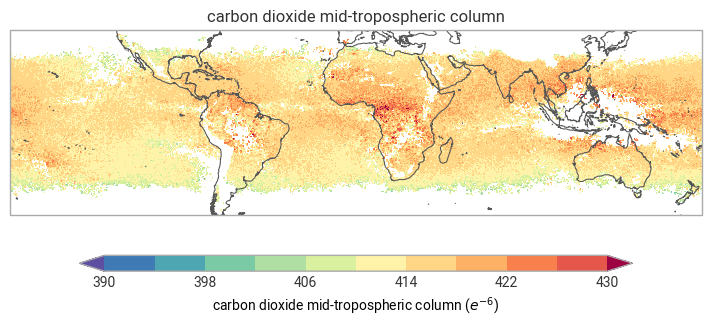

In [3]:
ekp.geo.contourf(satellite_data, style=co2_style)

In [4]:
gisco = ekg.gisco.countries().to_geopandas()

# Select rows for Brazil, DRC and Indonesia
gisco = gisco[gisco["NAME_ENGL"].isin(["Brazil", "Democratic Republic of The Congo", "Indonesia"])]
gisco

,CNTR_ID,COUNTRY_UR,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,STAT_CODE,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
6,BR,BRA,Brasil,Brazil,Brésil,BRA,UN Member State,Brasília,OA,F,F,F,Brasilien,"MULTIPOLYGON (((-60.13162 5.23374, -60.09657 5..."
42,CD,COD,République Démocratique du Congo-Kongo-Kongó-K...,Democratic Republic of The Congo,République démocratique du Congo,COD,UN Member State,Kinshasa,OA,F,F,F,Demokratische Republik Kongo,"POLYGON ((25.82479 5.20625, 25.94073 5.20072, ..."
98,ID,IDN,Indonesia,Indonesia,Indonésie,IDN,UN Member State,Jakarta,OA,F,F,F,Indonesien,"MULTIPOLYGON (((116.62695 4.34707, 116.69844 4..."


In [24]:
# Mask ERA5 data with geometry
masked = ekt.spatial.mask(
    satellite_data, gisco, mask_dim="NAME_ENGL", lon_key="longitude",
)
masked

<xarray.Dataset> Size: 14MB
Dimensions:       (NAME_ENGL: 3, sounding_dim: 381003)
Coordinates:
  * NAME_ENGL     (NAME_ENGL) object 24B 'Brazil' ... 'Indonesia'
  * sounding_dim  (sounding_dim) int64 3MB 0 1 2 3 ... 381000 381001 381002
    latitude      (sounding_dim) float32 2MB dask.array<chunksize=(381003,), meta=np.ndarray>
    longitude     (sounding_dim) float32 2MB dask.array<chunksize=(381003,), meta=np.ndarray>
    time          (sounding_dim) datetime64[ns] 3MB dask.array<chunksize=(381003,), meta=np.ndarray>
Data variables:
    co2           (NAME_ENGL, sounding_dim) float32 5MB dask.array<chunksize=(1, 381003), meta=np.ndarray>
Attributes: (12/36)
    title:                     NLIS
    institution:               Laboratoire de Météorologie Dynamique (LMD) - ...
    source:                    
    history:                   
    reference:                 Crevoisier et al., ACP, 2009, 2013
    tracking_id:               0ecf28e1-68ca-4e4c-8db9-3fbc1ebdfeca
    ...                        ...
    time_coverage_resolution:  P1D
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    license:                   ESA CCI Data Policy: free and open access
    platform:                  Metop-C
    sensor:                    IASI
    spatial_resolution:

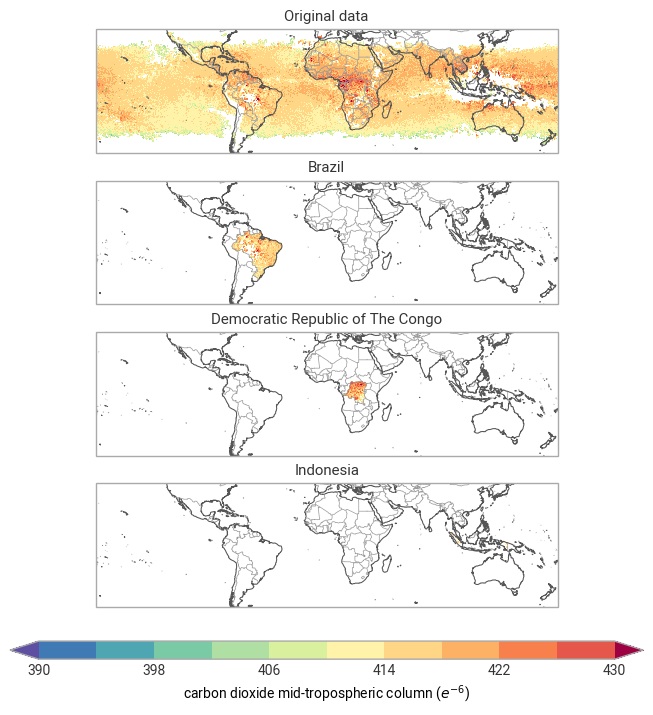

In [ ]:
figure = ekp.Figure(rows=4, columns=1)
nmaps = figure.rows * figure.columns

subplot = figure.add_map()
subplot.contourf(satellite_data, style=co2_style)
subplot.title("Original data")

for i in range(nmaps-1):
    _p_data = masked.isel(NAME_ENGL=i)
    subplot = figure.add_map()
    subplot.contourf(
        _p_data,
        style=co2_style,
        # interpolate={"distance_threshold": "auto"},
    )
    subplot.title("{NAME_ENGL}")

figure.coastlines()
figure.borders()
figure.legend()
figure.show()